<h1 dir="rtl" style="font-family: Vazir; width: 85%;">تمرین شماره 2
: درس بازیابی هوشمند اطلاعات - دانشگاه تهران، پائیز ۱۴۰۳</h1>

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
نام: عرفان شهابی
<br/>


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px; color: red; font-weight: bold;">
به جهت کم شدن حجم فایل آپلود شده در سایت، فولدر دیتا را پاک کرده ام لطفا زمان ران کردن کد ها این موضوع را در نظر داشته باشید. با تشکر
</div>

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
سوالات خودتان را می‌توانید از طریق ایمیل
<code>roshandel.amir@ut.ac.ir</code>
 از طراح تمرین 2 بپرسید.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px; color: red; font-weight: bold;">
قوانین و توضیحاتی آخر فایل تمرین حتما به دقت مطالعه شود.
</div>

In [1]:
!pip install nltk
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
import document_processing as dp
import inverted_index as ii
import query_processing as qp
import evaluation as ev

In [3]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload to Mode 1: Reload modules only when explicitly imported
%autoreload 1

# Mark specific modules for autoreloading
%aimport retrieval_models


import retrieval_models as rm

In [1]:
# Ensure NLTK data is downloaded
import nltk
import numpy as np
import pandas as pd

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/erfanshahabi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/erfanshahabi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **سوال اول:**

## Loading the dataset


In [4]:
# Paths to data files
corpus_file = 'data/LA.xml' #LA.xml
query_file = 'data/topics.xml' #topics.xml
relevance_file = 'data/jud-la.txt' #jud-la.txt
stopwords_file = 'data/stops_en.txt' #stops_en.txt

In [5]:
# 1. Data Loading and Preprocessing
dataset_type = 'type2'
# Load stopwords
stop_words = dp.load_stopwords(stopwords_file)

print("Loading and preprocessing documents...")
documents = dp.load_documents(corpus_file, dataset_type=dataset_type)
for idx, doc in enumerate(documents):
    doc.preprocess(stop_words=stop_words)
    if (idx + 1) % 100 == 0 or idx == len(documents) - 1:
        print(f"Processed {idx+1}/{len(documents)} documents")

print("Building inverted index...")
inverted_index = ii.InvertedIndex()
inverted_index.build_index(documents)

print("Loading and preprocessing queries...")
queries = qp.load_queries(query_file, dataset_type=dataset_type)
for query in queries:
    query.preprocess(stop_words=stop_words)

print("Loading relevance judgments...")
relevance_judgments = ev.load_relevance_judgments(relevance_file)

Loading and preprocessing documents...
Processed 100/113005 documents
Processed 200/113005 documents
Processed 300/113005 documents
Processed 400/113005 documents
Processed 500/113005 documents
Processed 600/113005 documents
Processed 700/113005 documents
Processed 800/113005 documents
Processed 900/113005 documents
Processed 1000/113005 documents
Processed 1100/113005 documents
Processed 1200/113005 documents
Processed 1300/113005 documents
Processed 1400/113005 documents
Processed 1500/113005 documents
Processed 1600/113005 documents
Processed 1700/113005 documents
Processed 1800/113005 documents
Processed 1900/113005 documents
Processed 2000/113005 documents
Processed 2100/113005 documents
Processed 2200/113005 documents
Processed 2300/113005 documents
Processed 2400/113005 documents
Processed 2500/113005 documents
Processed 2600/113005 documents
Processed 2700/113005 documents
Processed 2800/113005 documents
Processed 2900/113005 documents
Processed 3000/113005 documents
Processed 

## Example

In [6]:
print("\nSample run with BM25 (k=1.5, b=0.75)")
params = {'k': 1.5, 'b': 0.75}
evaluation_results = ev.evaluate_scoring_method(inverted_index,rm.bm25_score, queries, relevance_judgments, params=params)
print(evaluation_results)
print(f"MAP for BM25 (k={1.5}, b={0.75}): {evaluation_results['MAP']}")


Sample run with BM25 (k=1.5, b=0.75)
{'MAP': 0.3672, 'Precision@5': 0.422, 'Recall@10': 0.3102, 'nDCG@5': 0.5081}
MAP for BM25 (k=1.5, b=0.75): 0.3672



Running with large steps...

Fine-tuning around best delta = 150.1...
Best MAP achieved at delta = 149.1: 0.3005
{'MAP': 0.3005, 'Precision@5': 0.362, 'Recall@10': 0.2765, 'nDCG@5': 0.4191}


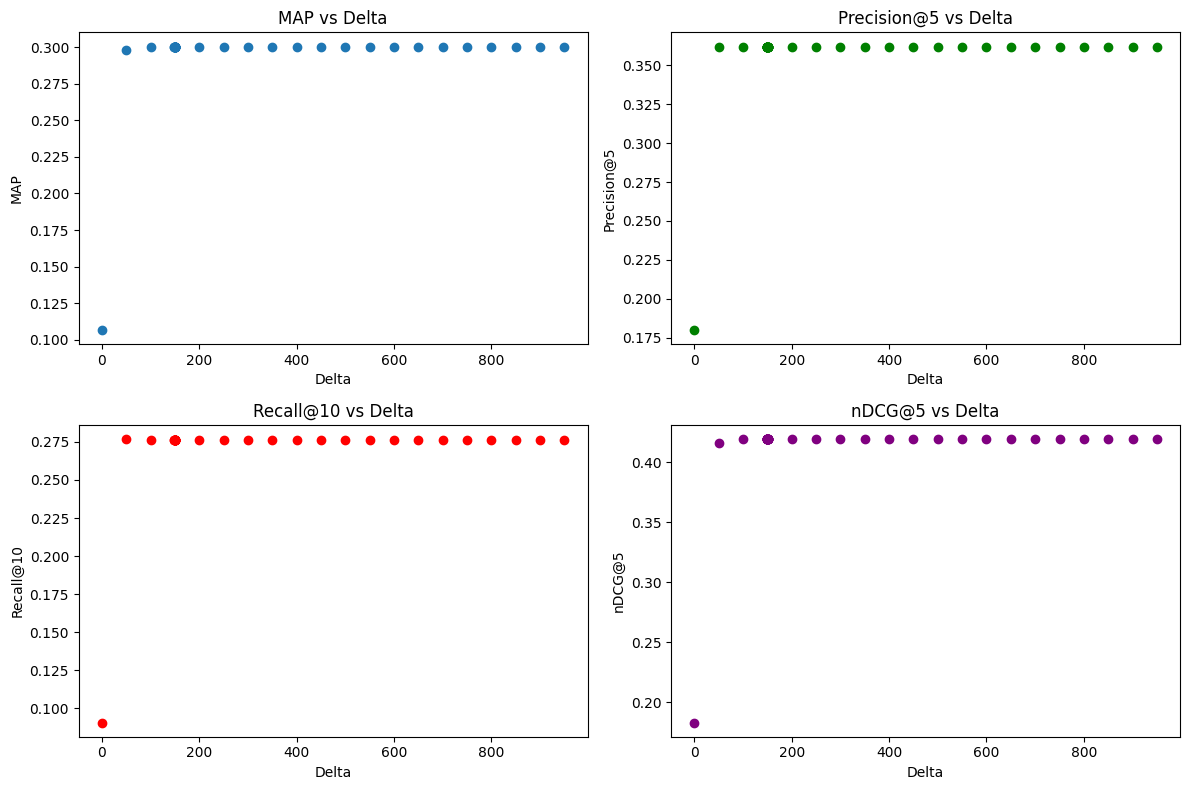

In [35]:
#YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt


deltas_big_steps = np.arange(0.1, 1000, 50)  # large steps


best_map = 0
best_delta = 0
results = {'delta': [], 'MAP': [], 'Precision@5': [], 'Recall@10': [], 'nDCG@5': []}


def evaluate_and_store(delta):
    params = {'delta': delta}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.additive_smoothing, queries, relevance_judgments, params=params)
    
    map_value = evaluation_results['MAP']
    precision_at_5 = evaluation_results['Precision@5']
    recall_at_10 = evaluation_results['Recall@10']
    ndcg_value = evaluation_results['nDCG@5']
    
    results['delta'].append(delta)
    results['MAP'].append(map_value)
    results['Precision@5'].append(precision_at_5)
    results['Recall@10'].append(recall_at_10)
    results['nDCG@5'].append(ndcg_value)
    
    return map_value


print("\nRunning with large steps...")
for delta in deltas_big_steps:
    map_value = evaluate_and_store(delta)
    if map_value > best_map:
        best_map = map_value
        best_delta = delta

# small steps
print(f"\nFine-tuning around best delta = {best_delta}...")
fine_tune_range = np.arange(max(0.1, best_delta - 1), best_delta + 1, 0.1)
for delta in fine_tune_range:
    map_value = evaluate_and_store(delta)
    if map_value > best_map:
        best_map = map_value
        best_delta = delta

print(f"Best MAP achieved at delta = {best_delta}: {best_map}")
params = {'delta': best_delta}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.additive_smoothing, queries, relevance_judgments, params=params)
print(evaluation_results)

plt.figure(figsize=(12, 8))

# MAP
plt.subplot(2, 2, 1)
plt.scatter(results['delta'], results['MAP'], label='MAP')
plt.xlabel('Delta')
plt.ylabel('MAP')
plt.title('MAP vs Delta')

# Precision@5
plt.subplot(2, 2, 2)
plt.scatter(results['delta'], results['Precision@5'], label='Precision@5', color='green')
plt.xlabel('Delta')
plt.ylabel('Precision@5')
plt.title('Precision@5 vs Delta')

# Recall@10
plt.subplot(2, 2, 3)
plt.scatter(results['delta'], results['Recall@10'], label='Recall@10', color='red')
plt.xlabel('Delta')
plt.ylabel('Recall@10')
plt.title('Recall@10 vs Delta')

# nDCG
plt.subplot(2, 2, 4)
plt.scatter(results['delta'], results['nDCG@5'], label='nDCG', color='purple')
plt.xlabel('Delta')
plt.ylabel('nDCG@5')
plt.title('nDCG@5 vs Delta')

plt.tight_layout()
plt.show()



<div style="direction: rtl; text-align: right;">
    در این کد سعی بر آن شده تابع additive smoothing نوشته شده در فایل retrieval_models پیاده سازی شود.
    ابتدا با استفاده از کتابخانه numpy بازه ای بین ۰.۱و ۱۰۰۰ ایجاد میشود که در قدم اول برنامه این بازه را ۵۰ تا ۵۰ تا پیمایش میکند.
    سپس تابعی نوشته شده که به ازای هر مقدار دلتا معیارهای ارزیابی را محاسبه کرده و در
    نهایت این مقادیر را در لیست مربوطه ذخیره نماید.
    سپس بر اساس بیشترین مقدار map به دست آمده، مقدار بهینه دلتا با گام های بزرگ مشخص میشود و در مرحله بعد این حول این مقدار، دلتا با گام های کوچک محاسبه میشود و بر اساس بیشترین map به دست آمده بهینه ترین مقدار دلتا مشخص شده و نمودارهای تغییرات معیار ها بر حسب دلتا رسم میشود.
    <br><br>
    طبق محاسبات انجام شده بیشترین مقدار مپ با دلتا برابر 149.1 به دست آمده و مقادیر معیار های ارزیابی بر اساس این دلتا برابر زیراند:
    {'MAP': 0.3005, 'Precision@5': 0.362, 'Recall@10': 0.2765, 'nDCG@5': 0.4191}
    همانطور که در نمودار map مشخص است، مقدار دلتا در بازه ۰ تا ۱۰۰ به صورت نمایی رشد میکند و این به دلیل آن است که طبق این روش به ترم هایی با احتمال ۰، احتمالی اختصاص می دهیم تا هموار سازی انجام شود.
    به دلیل بزرگ بودن بازه پیمایش نقطه ای بین ۰ تا ۱۰۰ دیده نمیشود.
    مقدار همه معیار ها بعد از مقدار بهینه دلتا، کاهشی بوده اما این کاهش چشم گیر نیست. و در نهایت مقدار دلتای بهینه برابر 149.1 می باشد.
    


Running with large steps...

Fine-tuning around best lambda = 0.1...
Best MAP achieved at lambda = 0.1: 0.0887
{'MAP': 0.0887, 'Precision@5': 0.116, 'Recall@10': 0.1002, 'nDCG@5': 0.1192}


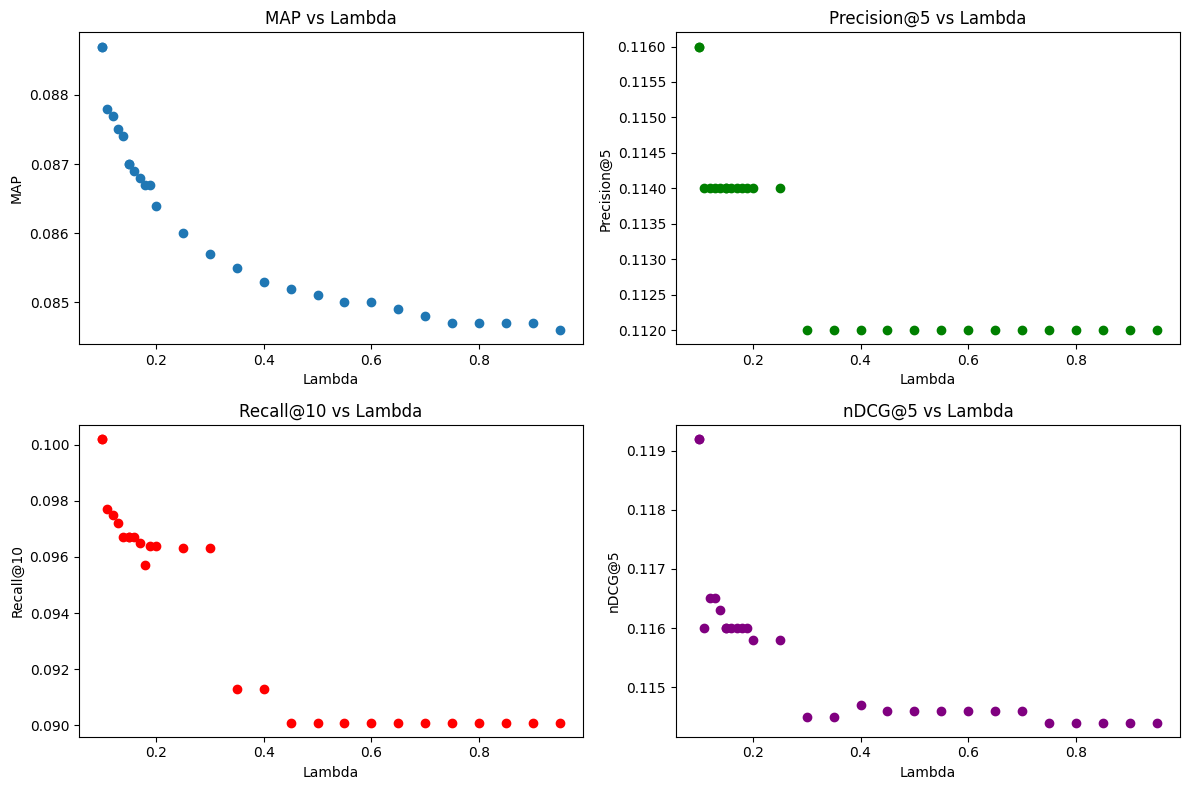

In [36]:
#YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt

lambda_params = np.arange(0.1, 1.0, 0.05)  # large steps

best_map = 0
best_lambda = 0
results = {'lambda': [], 'MAP': [], 'Precision@5': [], 'Recall@10': [], 'nDCG@5': []}

def evaluate_and_store(lambda_param):
    params = {'lambda_param': lambda_param}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.jm_smoothing, queries, relevance_judgments, params=params)
    
    map_value = evaluation_results['MAP']
    precision_at_5 = evaluation_results['Precision@5']
    recall_at_10 = evaluation_results['Recall@10']
    ndcg_value = evaluation_results['nDCG@5']
    
    results['lambda'].append(lambda_param)
    results['MAP'].append(map_value)
    results['Precision@5'].append(precision_at_5)
    results['Recall@10'].append(recall_at_10)
    results['nDCG@5'].append(ndcg_value)
    
    return map_value


print("\nRunning with large steps...")
for lambda_param in lambda_params:
    map_value = evaluate_and_store(lambda_param)
    if map_value > best_map:
        best_map = map_value
        best_lambda = lambda_param

# small steps
print(f"\nFine-tuning around best lambda = {best_lambda}...")
fine_tune_range = np.arange(max(0.1, best_lambda - 0.1), best_lambda + 0.1, 0.01)
for lambda_param in fine_tune_range:
    map_value = evaluate_and_store(lambda_param)
    if map_value > best_map:
        best_map = map_value
        best_lambda = lambda_param

print(f"Best MAP achieved at lambda = {best_lambda}: {best_map}")
params = {'lambda_param': best_lambda}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.jm_smoothing, queries, relevance_judgments, params=params)
print(evaluation_results)


plt.figure(figsize=(12, 8))

# MAP
plt.subplot(2, 2, 1)
plt.scatter(results['lambda'], results['MAP'], label='MAP')
plt.xlabel('Lambda')
plt.ylabel('MAP')
plt.title('MAP vs Lambda')

# Precision@5
plt.subplot(2, 2, 2)
plt.scatter(results['lambda'], results['Precision@5'], label='Precision@5', color='green')
plt.xlabel('Lambda')
plt.ylabel('Precision@5')
plt.title('Precision@5 vs Lambda')

# Recall@10
plt.subplot(2, 2, 3)
plt.scatter(results['lambda'], results['Recall@10'], label='Recall@10', color='red')
plt.xlabel('Lambda')
plt.ylabel('Recall@10')
plt.title('Recall@10 vs Lambda')

# nDCG@5
plt.subplot(2, 2, 4)
plt.scatter(results['lambda'], results['nDCG@5'], label='nDCG', color='purple')
plt.xlabel('Lambda')
plt.ylabel('nDCG@5')
plt.title('nDCG@5 vs Lambda')

plt.tight_layout()
plt.show()



<div style="direction: rtl; text-align: right;">
    هدف این کد پیدا کردن مقدار بهینه لاندای تابع پیاده سازی شده برای مدل هموارسازی jm در فایل retrieval_models است.
    لاندا مقداری بین ۰ و ۱ دارد که با استفاده از کتابخانه numpy بازه بین ۰ و ۱ با پیمایش ۰.۰۵ تعریف شده است.
    سپس تابعی نوشته شده که به ازای مقادیر پیمایش شده در این بازه مقادیر معیارهای ارزیابی را به دست آورد و بر اساس مقدار بیشینه معیار map، مقدار بهینه لاندا با گام های بزرگ به دست می آید.
    سپس حول این مقدار بهینه، معیارهای ارزیابی با گام های کوچم ۰.۰۱ را به دست می آوریم و بر اساس بیشینه map در این مرحله مقدار بهینه لاندا را محاسبه میکنیم.
    مقدار بهینه لاندا با این روش عدد 0.0887 به دست آمده است که با این مقدار لاندا مقادیر معیار های ارزیابی به شرح زیراند:
    {'MAP': 0.0887, 'Precision@5': 0.116, 'Recall@10': 0.1002, 'nDCG@5': 0.1192}
    <br><br>
    معیار های ارزیابی به دست آمده نشان میدهد این مدل برای اسناد موجود به خوبی کار نمیکند. مقدار precision@5 با این روش برابر ۰.۱۱۶ شده است که نشان میدهد ۱۱ درصد اسناد نمایش داده شده در ۵ نمایش اول سندهای مرتبط بوده اند. همچنین مقدار recall@10 این روش برابر ۰.۱۰۰۲ بوده که نشان میدهد تنها ۱۰ درصد اسناد مرتبط بین ۱۰ سند اول نمایش داده شده بازیابی شده است. 
    مقدار nDCG@5 این روش برابر ۰.۱۱۹۲ است که نشان میدهد بین ۵ سند اول نمایش داده شده تنها ۱۱ درصد اسناد مرتبط در رتبه های بالاتر قرار داشته اند.
    <br><br>
    همچنین نمودار های رسم شده نشان میدهند که بیشترین مقدار همه معیار ها حول نقطه دلتا برابر ۰.۱ بوده اند و از این نقطه به بعد مقدار این معیار ها با شیب بسیار زیادی نزولی بوده است. این نشان میدهد که که بهتر است که احتمال بیش از ۹۲ درصد ترم ها از بین کالکشن محاسبه شود و تنها احتمال ۸ درصد ترم ها در اسناد مورد جست و جو قرار گیرد.
<div>


Running with large steps...

Fine-tuning around best m = 100.1...
Best MAP achieved at m = 100.1: 0.1391
{'MAP': 0.1391, 'Precision@5': 0.216, 'Recall@10': 0.1437, 'nDCG@5': 0.2377}


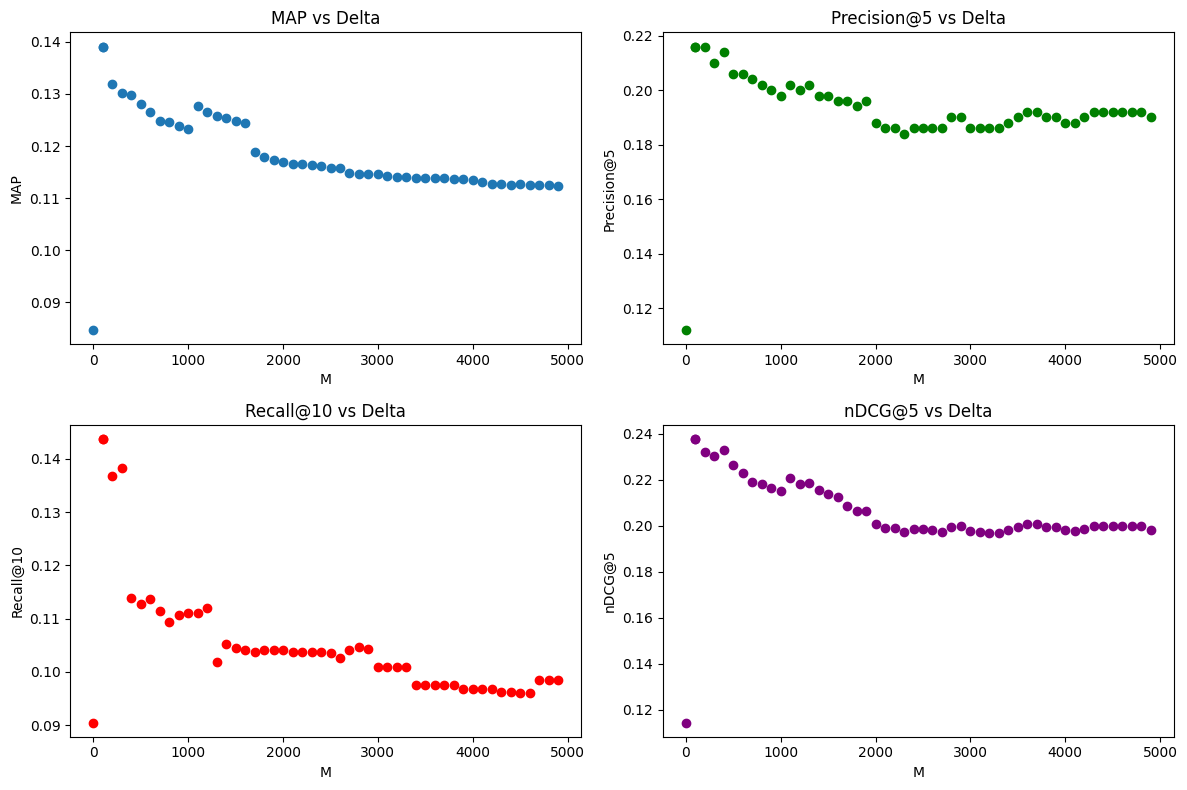

In [41]:
#YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt


deltas_big_steps = np.arange(0.1, 5000, 100)  # large steps


best_map = 0
best_m = 0
results = {'m': [], 'MAP': [], 'Precision@5': [], 'Recall@10': [], 'nDCG@5': []}

def evaluate_and_store(m):
    params = {'m': m}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.dirichlet_prior, queries, relevance_judgments, params=params)
    
    map_value = evaluation_results['MAP']
    precision_at_5 = evaluation_results['Precision@5']
    recall_at_10 = evaluation_results['Recall@10']
    ndcg_value = evaluation_results['nDCG@5']
    
    results['m'].append(m)
    results['MAP'].append(map_value)
    results['Precision@5'].append(precision_at_5)
    results['Recall@10'].append(recall_at_10)
    results['nDCG@5'].append(ndcg_value)
    
    return map_value


print("\nRunning with large steps...")
for m in deltas_big_steps:
    map_value = evaluate_and_store(m)
    if map_value > best_map:
        best_map = map_value
        best_m = m

# small steps
print(f"\nFine-tuning around best m = {best_m}...")
fine_tune_range = np.arange(max(0.1, best_m - 0.1), best_m + 0.1, 1)
for m in fine_tune_range:
    map_value = evaluate_and_store(m)
    if map_value > best_map:
        best_map = map_value
        best_m = m

print(f"Best MAP achieved at m = {best_m}: {best_map}")
params = {'m': best_m}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.dirichlet_prior, queries, relevance_judgments, params=params)
print(evaluation_results)


plt.figure(figsize=(12, 8))

# MAP
plt.subplot(2, 2, 1)
plt.scatter(results['m'], results['MAP'], label='MAP')
plt.xlabel('M')
plt.ylabel('MAP')
plt.title('MAP vs Delta')

# Precision@5
plt.subplot(2, 2, 2)
plt.scatter(results['m'], results['Precision@5'], label='Precision@5', color='green')
plt.xlabel('M')
plt.ylabel('Precision@5')
plt.title('Precision@5 vs Delta')

# Recall@10
plt.subplot(2, 2, 3)
plt.scatter(results['m'], results['Recall@10'], label='Recall@10', color='red')
plt.xlabel('M')
plt.ylabel('Recall@10')
plt.title('Recall@10 vs Delta')

# nDCG
plt.subplot(2, 2, 4)
plt.scatter(results['m'], results['nDCG@5'], label='nDCG', color='purple')
plt.xlabel('M')
plt.ylabel('nDCG@5')
plt.title('nDCG@5 vs Delta')

plt.tight_layout()
plt.show()



<div style="direction: rtl; text-align: right;">
    هدف این کد پیدا کردن مقدار بهینه لاندای تابع پیاده سازی شده برای مدل هموارسازی dirichlet perior در فایل retrieval_models است.
    مو مقداری بزرگتر از ۰ دارد که با استفاده از کتابخانه numpy بازه بین 0 و 5000 با پیمایش 100 تعریف شده است.
    سپس تابعی نوشته شده که به ازای مقادیر پیمایش شده در این بازه مقادیر معیارهای ارزیابی را به دست آورد و بر اساس مقدار بیشینه معیار map، مقدار بهینه مو با گام های بزرگ به دست می آید.
    سپس حول این مقدار بهینه، معیارهای ارزیابی با گام های کوچم ۱ را به دست می آوریم و بر اساس بیشینه map در این مرحله مقدار بهینه مو را محاسبه میکنیم.
    مقدار بهینه مو با این روش عدد 100.1 به دست آمده است که با این مقدار مو مقادیر معیار های ارزیابی به شرح زیراند:
    {'MAP': 0.1391, 'Precision@5': 0.216, 'Recall@10': 0.1437, 'nDCG@5': 0.2377}
    <br><br>
    معیار های ارزیابی به دست آمده نشان میدهد این مدل برای اسناد موجود به خوبی کار نمیکند اما نسبت به مدل jm بهتر است. مقدار precision@5 با این روش برابر 0.216 شده است که نشان میدهد 21.6 درصد اسناد نمایش داده شده در ۵ نمایش اول سندهای مرتبط بوده اند. همچنین مقدار recall@10 این روش برابر 0.1437 بوده که نشان میدهد تنها 14 درصد اسناد مرتبط بین ۱۰ سند اول نمایش داده شده بازیابی شده است. 
    مقدار nDCG@5 این روش برابر ۰.2377 است که نشان میدهد بین ۵ سند اول نمایش داده شده 23 درصد اسناد مرتبط در رتبه های بالاتر قرار داشته اند.
    <br><br>
    همچنین نمودار های رسم شده نشان میدهند که بیشترین مقدار همه معیار ها حول نقطه مو برابر ۱۰۰.۱ بوده اند و از این نقطه به بعد مقدار این معیار ها با شیب بسیار زیادی نزولی بوده است.
<div>


Running with large steps...

Fine-tuning around best m = 0.1 and lambda = 0.6000000000000001...
Best MAP achieved at m = 0.1 and lambda_param = 0.6000000000000001: 0.3235
{'MAP': 0.3235, 'Precision@5': 0.39, 'Recall@10': 0.3034, 'nDCG@5': 0.4502}


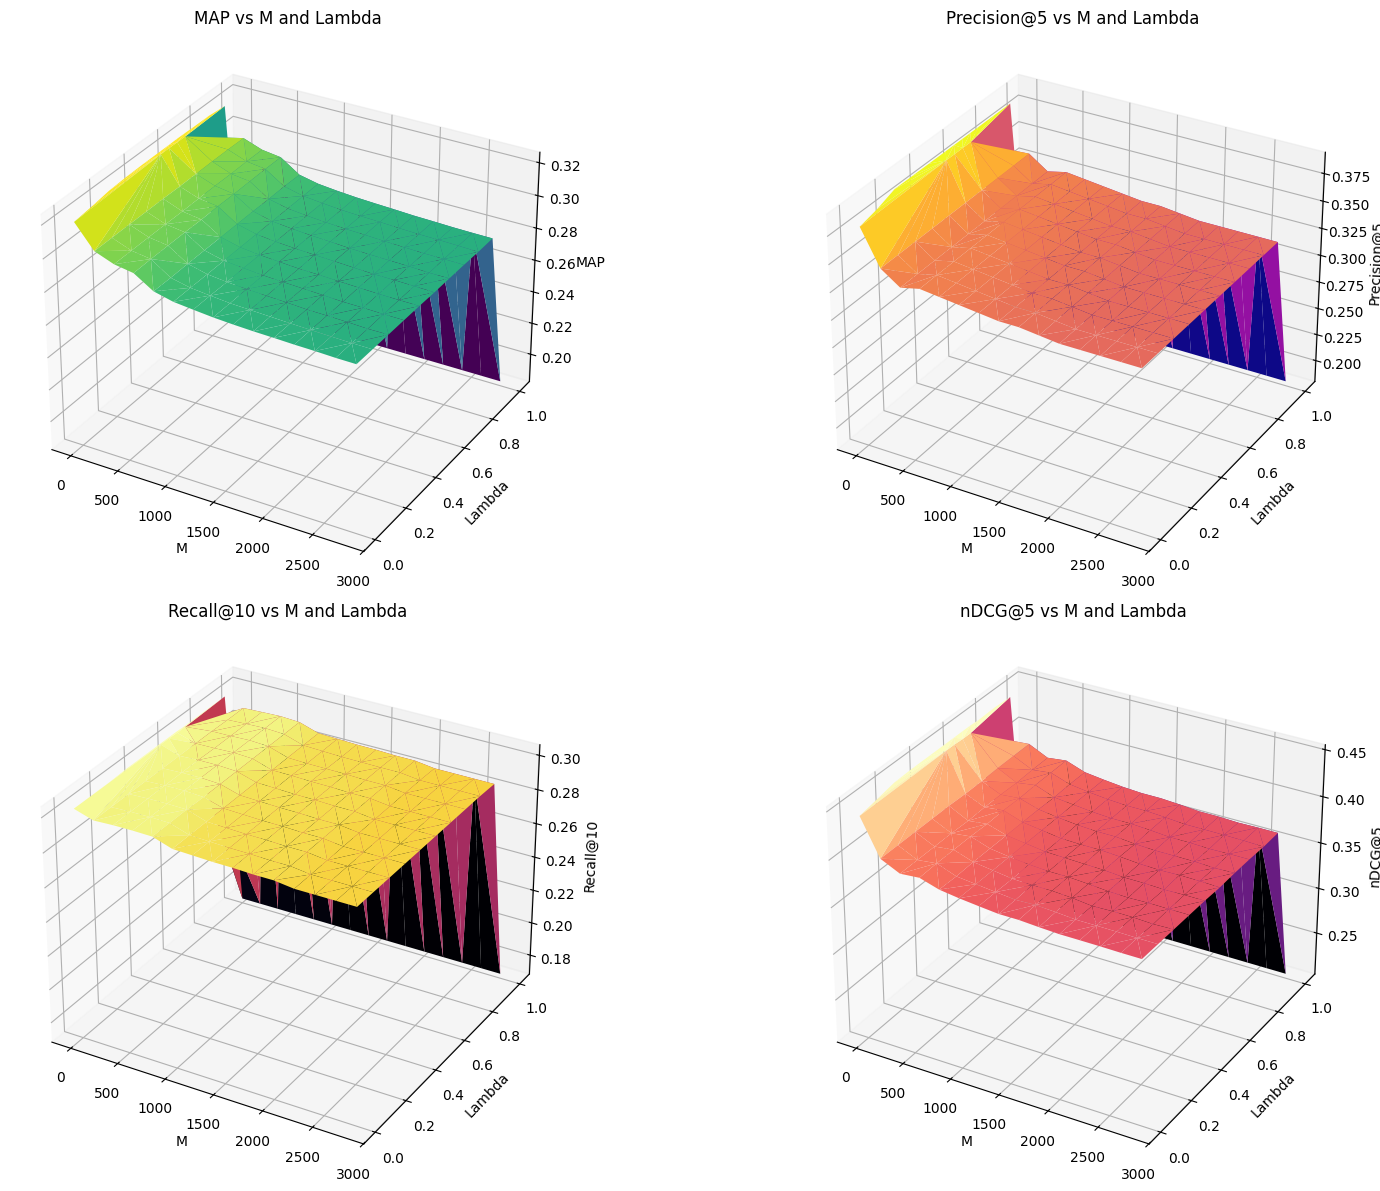

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D

lambda_params = np.arange(0, 1.1, 0.1)  
m = np.arange(0.1, 3000, 200) 

best_map = 0
best_m = 0
best_lambda = 0
results = {'m': [], 'lambda': [], 'MAP': [], 'Precision@5': [], 'Recall@10': [], 'nDCG@5': []}


def evaluate_and_store(lambda_param, m):
    params = {'lambda_param': lambda_param, 'm': m}  
    evaluation_results = ev.evaluate_scoring_method(
        inverted_index, 
        rm.twin_model, 
        queries, 
        relevance_judgments, 
        params=params
    )
    
    map_value = evaluation_results['MAP']
    precision_at_5 = evaluation_results['Precision@5']
    recall_at_10 = evaluation_results['Recall@10']
    ndcg_value = evaluation_results['nDCG@5']
    
    results['m'].append(m)
    results['lambda'].append(lambda_param)
    results['MAP'].append(map_value)
    results['Precision@5'].append(precision_at_5)
    results['Recall@10'].append(recall_at_10)
    results['nDCG@5'].append(ndcg_value)
    
    return map_value

# large steps
print("\nRunning with large steps...")
for m_value in m:  
    for lambda_param in lambda_params:
        map_value = evaluate_and_store(lambda_param, m_value)  
        if map_value > best_map:
            best_map = map_value
            best_m = m_value
            best_lambda = lambda_param

# small steps
print(f"\nFine-tuning around best m = {best_m} and lambda = {best_lambda}...")
fine_tune_range_m = np.arange(max(0.1, best_m - 10), best_m + 10, 5)
fine_tune_range_lambda = np.arange(max(0.0, best_lambda - 0.1), min(1.0, best_lambda + 0.1), 0.05)

for m in fine_tune_range_m:
    for lambda_param in fine_tune_range_lambda:
        map_value = evaluate_and_store(lambda_param, m)
        if map_value > best_map:
            best_map = map_value
            best_m = m
            best_lambda = lambda_param

print(f"Best MAP achieved at m = {best_m} and lambda_param = {best_lambda}: {best_map}")
params = {'lambda_param':best_lambda, 'm': best_m}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.twin_model, queries, relevance_judgments, params=params)
print(evaluation_results)


fig = plt.figure(figsize=(18, 12))

# MAP
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_trisurf(results['m'], results['lambda'], results['MAP'], cmap='viridis', edgecolor='none')
ax1.set_xlabel('M')
ax1.set_ylabel('Lambda')
ax1.set_zlabel('MAP')
ax1.set_title('MAP vs M and Lambda')

# Precision@5
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot_trisurf(results['m'], results['lambda'], results['Precision@5'], cmap='plasma', edgecolor='none')
ax2.set_xlabel('M')
ax2.set_ylabel('Lambda')
ax2.set_zlabel('Precision@5')
ax2.set_title('Precision@5 vs M and Lambda')

# Recall@10
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot_trisurf(results['m'], results['lambda'], results['Recall@10'], cmap='inferno', edgecolor='none')
ax3.set_xlabel('M')
ax3.set_ylabel('Lambda')
ax3.set_zlabel('Recall@10')
ax3.set_title('Recall@10 vs M and Lambda')

# nDCG@5
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot_trisurf(results['m'], results['lambda'], results['nDCG@5'], cmap='magma', edgecolor='none')
ax4.set_xlabel('M')
ax4.set_ylabel('Lambda')
ax4.set_zlabel('nDCG@5')
ax4.set_title('nDCG@5 vs M and Lambda')

plt.tight_layout()
plt.show()


<div style="direction: rtl; text-align: right;">
    در این کد سعی بر آن شده تابع هموارسازی دو مرحله ای که تر کیبی از مدل jm و مدل dirichlet است نوشته شده در فایل retrieval_models پیاده سازی شود.
    ابتدا با استفاده از کتابخانه numpy بازه ای بین ۰.۱و ۱ برای لاندا و بازه ای بین ۰.۱ تا ۳۰۰۰ برای مو ایجاد میشود.
    سپس تابعی نوشته شده که به ازای هر مقدار مو و لاندا معیارهای ارزیابی را محاسبه کرده و در
    نهایت این مقادیر را در لیست مربوطه ذخیره نماید.
    سپس بر اساس بیشترین مقدار map به دست آمده، مقدار بهینه این دو پارامتر با گام های بزرگ مشخص میشود و در مرحله بعد این حول این مقادیر، لاندا و مو با گام های کوچک محاسبه میشود و بر اساس بیشترین map به دست آمده بهینه ترین مقدار این دو پارامتر مشخص شده و نمودارهای تغییرات معیار ها بر حسب دلتا رسم میشود.
    <br><br>
    طبق محاسبات انجام شده بیشترین مقدار مپ با مو برابر 0.1 و لاندا برابر 0.6 به دست آمده و مقادیر معیار های ارزیابی بر اساس این مقادیر برابر زیراند:
   {'MAP': 0.3235, 'Precision@5': 0.39, 'Recall@10': 0.3034, 'nDCG@5': 0.4502}
   معیار های ارزیابی در این روش نسبت به روش های پیشین مقادیر بهتری دارند. precision@5 در این روش برابر ۰.۳۹ است که نشان دهنده این است در ۵ سند اول نمایش داده شده، ۳۹ درصد اسناد مرتبط هستند. recall برابر با ۰.۳۰۳۴ است که بدین معناست در بین ۱۰ سند اول نمایش داده شده، ۳۰ درصد اسناد مرتبط بازیابی شده است، مقدار nDCG@5 هم برابر ۰.۴۵۰۲ است که نشان میدهد در بین ۵ سند اول نمایش داده شده، ۴۵ درصد اسناد مرتبط در رتبه های اول نمایش داده میشوند.
   <br><br>
   با توجه به سه پارامتری بودن این سوال، من نمودار ها را به صورت سه بعدی رسم کرده ام، بیتشرین مقدار map طبق این نمودار در نقطه ای با مو نزدیک به ۰.۱ و لاندا نزدیک به ۰.۶ است با افزایش این دو پارامتر بیش از این، مقدار map کاهش میابد.
   نمدار presicion@5 هم نشان می دهد مقدار این معیار در نزدیکی نقاط فوق بیشترین مقدار را دارند و با افزایش مو و لاندا مقدار معیار precision کاهش پیدا میکند.
   نمودار recall@10 هم نشان میدهد این معیار نیز در نقاط ذکر شده بیشترین مقدار را داشته و با افزایش مو و لاندا مقدار این معیار رو به کاهش می رود.
   نمودار nDCG@5 هم برای این مقادیر بیشترین مقدار را داشته و با افزایش مقادیر مو و لاندا رو به کاهش میرود.
   <br><br>
   این روش تلفیقی از روش jm و dirichlet prior است و مقدار لاندا به دست آمده بدان معناست که بهتر است ۴۰ درصد احتمالات از مجموعه رفرنس و حدود ۶۰ درصد احتمالات از مجموعه اسناد محاسبه شود.
    


Running with large steps...

Fine-tuning around best delta = 0.8...
Best MAP achieved at delta = 0.8800000000000002: 0.1048
{'MAP': 0.1094, 'Precision@5': 0.184, 'Recall@10': 0.0947, 'nDCG@5': 0.1872}


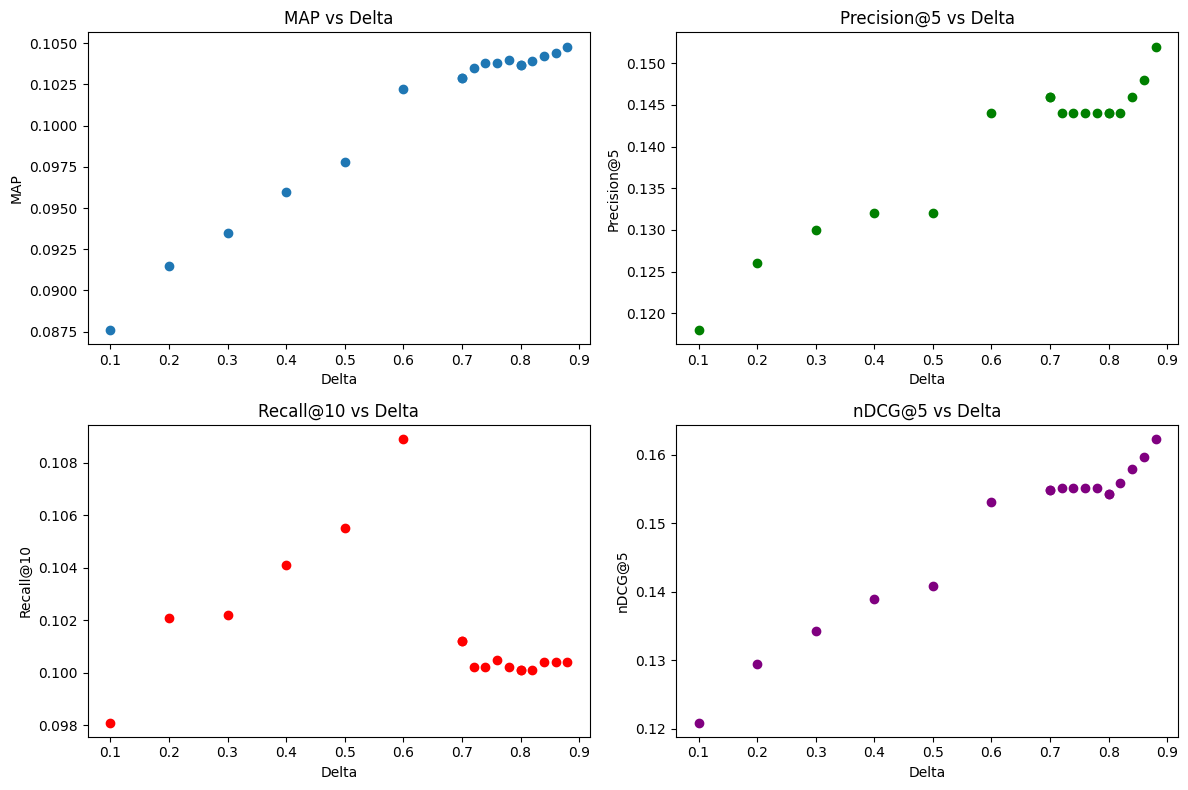

In [45]:
#YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt


deltas_big_steps = np.arange(0.1, 0.9, 0.1)  # گام‌های بزرگ


best_map = 0
best_delta = 0
results = {'delta': [], 'MAP': [], 'Precision@5': [], 'Recall@10': [], 'nDCG@5': []}

# large steps
def evaluate_and_store(delta):
    params = {'delta': delta}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.absolute_discounting, queries, relevance_judgments, params=params)
    
    map_value = evaluation_results['MAP']
    precision_at_5 = evaluation_results['Precision@5']
    recall_at_10 = evaluation_results['Recall@10']
    ndcg_value = evaluation_results['nDCG@5']
    
    results['delta'].append(delta)
    results['MAP'].append(map_value)
    results['Precision@5'].append(precision_at_5)
    results['Recall@10'].append(recall_at_10)
    results['nDCG@5'].append(ndcg_value)
    
    return map_value


print("\nRunning with large steps...")
for delta in deltas_big_steps:
    map_value = evaluate_and_store(delta)
    if map_value > best_map:
        best_map = map_value
        best_delta = delta

#small steps
print(f"\nFine-tuning around best delta = {best_delta}...")
fine_tune_range = np.arange(max(0.1, best_delta - 0.1), best_delta + 0.1, 0.02)
for delta in fine_tune_range:
    map_value = evaluate_and_store(delta)
    if map_value > best_map:
        best_map = map_value
        best_delta = delta

print(f"Best MAP achieved at delta = {best_delta}: {best_map}")
params = {'delta': best_delta}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.additive_smoothing, queries, relevance_judgments, params=params)
print(evaluation_results)


plt.figure(figsize=(12, 8))

# MAP
plt.subplot(2, 2, 1)
plt.scatter(results['delta'], results['MAP'], label='MAP')
plt.xlabel('Delta')
plt.ylabel('MAP')
plt.title('MAP vs Delta')

# Precision@5
plt.subplot(2, 2, 2)
plt.scatter(results['delta'], results['Precision@5'], label='Precision@5', color='green')
plt.xlabel('Delta')
plt.ylabel('Precision@5')
plt.title('Precision@5 vs Delta')

# Recall@10
plt.subplot(2, 2, 3)
plt.scatter(results['delta'], results['Recall@10'], label='Recall@10', color='red')
plt.xlabel('Delta')
plt.ylabel('Recall@10')
plt.title('Recall@10 vs Delta')

# nDCG
plt.subplot(2, 2, 4)
plt.scatter(results['delta'], results['nDCG@5'], label='nDCG', color='purple')
plt.xlabel('Delta')
plt.ylabel('nDCG@5')
plt.title('nDCG@5 vs Delta')

plt.tight_layout()
plt.show()



<div style="direction: rtl; text-align: right;">
    در این کد سعی بر آن شده تابع absolute discounting نوشته شده در فایل retrieval_models پیاده سازی شود.
    ابتدا با استفاده از کتابخانه numpy بازه ای بین 0,1, 0.9 ایجاد میشود که در قدم اول برنامه این بازه را 0.1 تا 0.1 تا پیمایش میکند.
    سپس تابعی نوشته شده که به ازای هر مقدار دلتا معیارهای ارزیابی را محاسبه کرده و در
    نهایت این مقادیر را در لیست مربوطه ذخیره نماید.
    سپس بر اساس بیشترین مقدار map به دست آمده، مقدار بهینه دلتا با گام های بزرگ مشخص میشود و در مرحله بعد این حول این مقدار، دلتا با گام های کوچک 0.02 محاسبه میشود و بر اساس بیشترین map به دست آمده بهینه ترین مقدار دلتا مشخص شده و نمودارهای تغییرات معیار ها بر حسب دلتا رسم میشود.
    <br><br>
    طبق محاسبات انجام شده بیشترین مقدار مپ با دلتا برابر 0.88 به دست آمده و مقادیر معیار های ارزیابی بر اساس این دلتا برابر زیراند:
    {'MAP': 0.1094, 'Precision@5': 0.184, 'Recall@10': 0.0947, 'nDCG@5': 0.1872}
     معیار های ارزیابی به دست آمده نشان میدهد این مدل برای اسناد موجود به خوبی کار نمیکند. مقدار precision@5 با این روش برابر 0.1094 شده است که نشان میدهد 10.9 درصد اسناد نمایش داده شده در ۵ نمایش اول سندهای مرتبط بوده اند. همچنین مقدار recall@10 این روش برابر ۰.0.0947 بوده که نشان میدهد تنها 9 درصد اسناد مرتبط بین ۱۰ سند اول نمایش داده شده بازیابی شده است. 
     همچنین معیار nDCG برای این مدل برابر 0.1872 بوده است که نشان دهنده این است که بین ۵ سند اول نمایش داده شده تنها ۱۸ درصد اسناد مرتبط در بالاترین رتبه ها قرار دارند.
     <br><br>
     در نمودار های map, precision, nDCG نمودار صعودی بوده و حول نقطه دلتا برابر با ۰.۸۸ بیشترین مقدار را دارد اما برای معیار recall این موضوع برقرار نیست و این نمودار نمایش می دهد با افزایش دلتا بیشتر از ۰.۶ مقدار recall رو به کاهش میرود و نشان دهنده این است که در مقادیر بالاتر دلتا اسناد کمتری از بین اسناد مرتبط بازیابی میشوند.
  
    

# **سوال دوم:**

EM Iterations: 100%|██████████| 50/50 [00:00<00:00, 730.30iter/s]


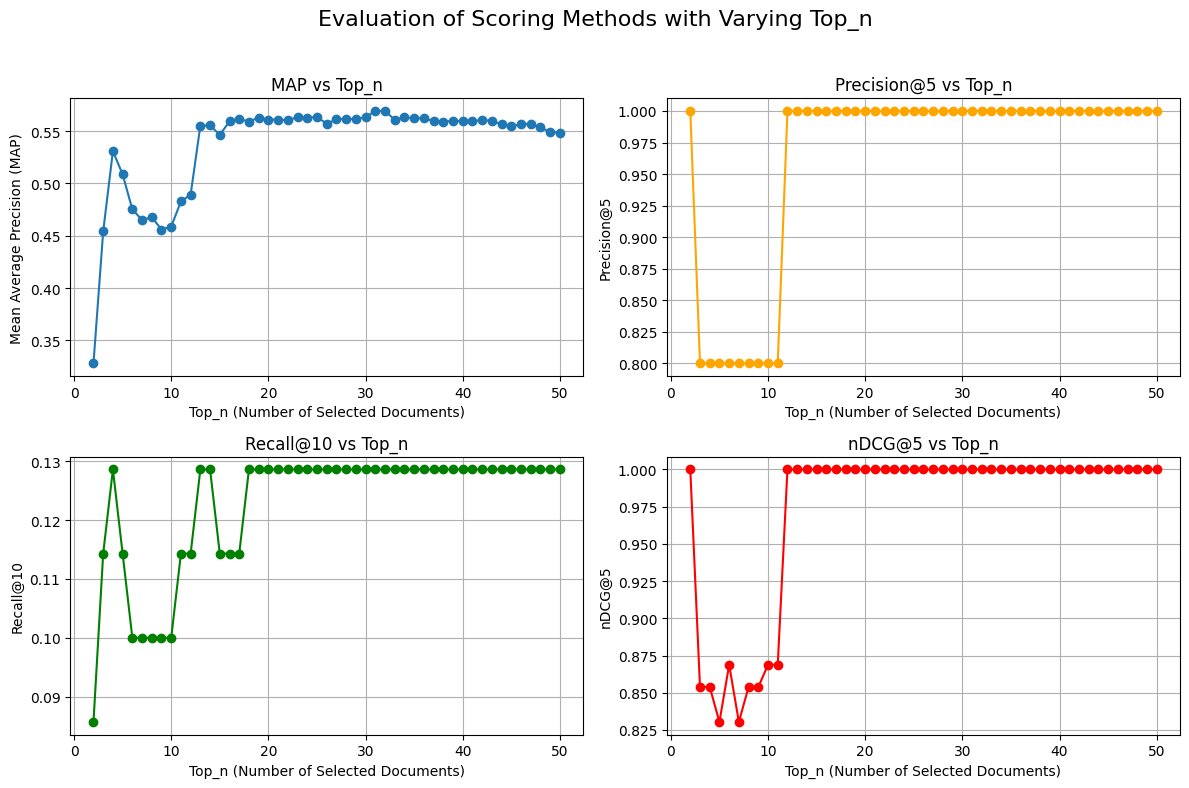

In [58]:
import matplotlib.pyplot as plt

top_n_values = range(2, 51)
map_scores = []
precision_at_5_scores = []
recall_at_10_scores = []
ndcg_scores = []


for top_n in top_n_values:
    params = {'k': 1.5, 'b': 0.75} 
    query2 = rm.mixture_model_prf(query, inverted_index, top_n= top_n, num_expansion_terms=10, max_iterations=50, convergence_threshold=1e-5, lambda_init=0.5)
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.bm25_score, [query2], relevance_judgments, params=params)
    map_scores.append(evaluation_results['MAP'])
    precision_at_5_scores.append(evaluation_results['Precision@5'])
    recall_at_10_scores.append(evaluation_results['Recall@10'])
    ndcg_scores.append(evaluation_results['nDCG@5'])


plt.figure(figsize=(12, 8))


plt.subplot(2, 2, 1)
plt.plot(top_n_values, map_scores, marker='o')
plt.title('MAP vs Top_n')
plt.xlabel('Top_n (Number of Selected Documents)')
plt.ylabel('Mean Average Precision (MAP)')
plt.grid()


plt.subplot(2, 2, 2)
plt.plot(top_n_values, precision_at_5_scores, marker='o', color='orange')
plt.title('Precision@5 vs Top_n')
plt.xlabel('Top_n (Number of Selected Documents)')
plt.ylabel('Precision@5')
plt.grid()


plt.subplot(2, 2, 3)
plt.plot(top_n_values, recall_at_10_scores, marker='o', color='green')
plt.title('Recall@10 vs Top_n')
plt.xlabel('Top_n (Number of Selected Documents)')
plt.ylabel('Recall@10')
plt.grid()


plt.subplot(2, 2, 4)
plt.plot(top_n_values, ndcg_scores, marker='o', color='red')
plt.title('nDCG@5 vs Top_n')
plt.xlabel('Top_n (Number of Selected Documents)')
plt.ylabel('nDCG@5')
plt.grid()

plt.suptitle('Evaluation of Scoring Methods with Varying Top_n', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


<div style="direction: rtl; text-align: right;">
    هدف از نوشتن این کد، نمایش رابطه بین تعداد اسناد منتخب برای بازخورد و معیارهای ارزیابی بوده است.
    در مرحله اول بازه ای بین ۲ تا ۵۰ برای اسناد منتخب برای بازخورد ایجاد میشود و در متغیر top_n_values ذخیره میگردد.
    سپس به ازای هر مقدار از این بازه با استفاده از تابع mixture_model کوئری اصلاح شده با توجه به بازخورد در متغیر query2 ذخیره می گردد.
    در مرحله بعد با توجه به این کوئری جدید با استفاده از روش BM25، معیار های ارزیابی محاسبه میشوند و در نهایت نمودار رابطه تعداد اسناد منتخب برای بازخورد و معیار های ارزیابی با استفاده از کتابخانه matplotlib رسم می گردد.
    <br><br>
    با توجه به نمودار رسم شده برای معیار map مشاهده میشود با استفاده از ۳۲ سند منتخب این معیار بیشترین مقدار خودش را میگیرد و با اضافه شدن تعداد اسناد منتخب این معیار کاهش می یابد.  این می‌تواند نشان‌دهنده این باشد که اضافه کردن اسناد بیشتر، دیگر کمکی به بهبود مرتبط بودن نتایج نمی‌کند و حتی ممکن است اسناد غیرمرتبط اضافه شود.
    <br>
    نمودار precision برای همه تعداد های اسناد منتخب بازخورد به جز بازه ۲ تا ۱۴ مقدار ثابتی را دارد و این مقدار برابر با ۱ است که نشان می دهد در بین ۵ سند بازیابی شده اول، ۱۰۰ درصد سند ها مرتبط هستند و 
    <br>
    نمودار recall با افزایش تعداد اسناد تا ۳ عدد رشد می کند و بعد از آن مقدار آن کاهشی میشود و دوباره صعود را تجربه میکند. بعد از تعداد ۱۸ سند مقدار آن ثابت و برابر ۰.۱۳ است یعنی در بین ۱۰ سند اول ۱۳ درصد اسناد مرتبط بازیابی شده اند و اضافه کردن اسناد منتخب بیشتر تغییری در بازیابی اسناد مرتبط بیشتر ایجاد نمی کند.
    <br>
    نمودار nDCG برای تعداد ۱ سند منتخب مقدار مناسبی را دارد ولی با افزایش تعداد اسناد منتخب نمودار شروع به نزول میکند و نشان دهنده آن است که تعداد اسناد منتخب بیشتر کمکی به رتبه اسناد مرتبط در ۵ سند بازیابی شده اول نمیکند. بعد از ۱۱ سند مرتبط نمودار دوباره صعودی شده و به بیشترین مقدار خود یعنی ۱ میرسد که بدان معناست همه سند های مرتبط بازیابی شده در ۵ سند اول در رتبه های بالای نمایش اسناد قرار دارند.
<div>

EM Iterations: 100%|██████████| 50/50 [00:00<00:00, 1383.46iter/s]


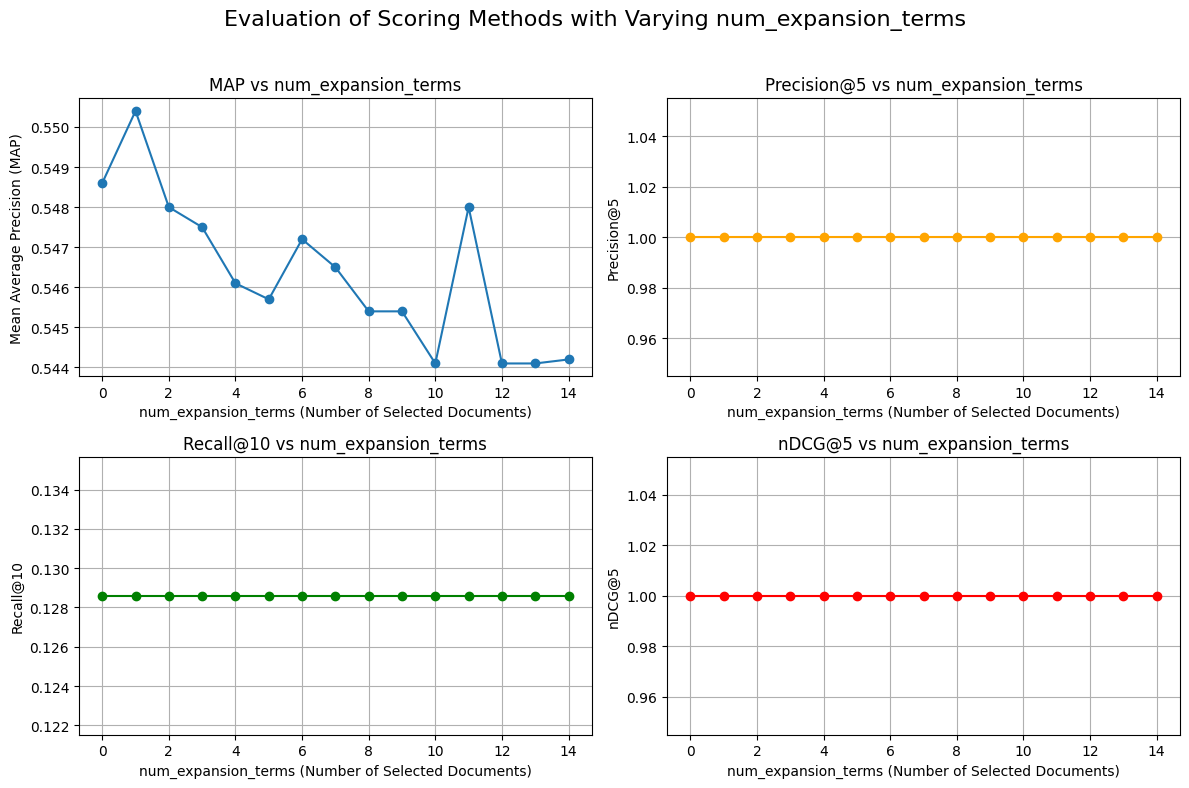

In [59]:
import matplotlib.pyplot as plt

num_expansion_terms = range(0, 15)  
map_scores = []
precision_at_5_scores = []
recall_at_10_scores = []
ndcg_scores = []

for num in num_expansion_terms:
    params = {'k': 1.5, 'b': 0.75}  
    query2 = rm.mixture_model_prf(query, inverted_index, top_n= 10, num_expansion_terms=num, max_iterations=50,
                      convergence_threshold=1e-5, lambda_init=0.5)
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.bm25_score, [query2], relevance_judgments, params=params)
    
   
    map_scores.append(evaluation_results['MAP'])
    precision_at_5_scores.append(evaluation_results['Precision@5'])
    recall_at_10_scores.append(evaluation_results['Recall@10'])
    ndcg_scores.append(evaluation_results['nDCG@5'])


plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(num_expansion_terms, map_scores, marker='o')
plt.title('MAP vs num_expansion_terms')
plt.xlabel('num_expansion_terms (Number of Selected Documents)')
plt.ylabel('Mean Average Precision (MAP)')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(num_expansion_terms, precision_at_5_scores, marker='o', color='orange')
plt.title('Precision@5 vs num_expansion_terms')
plt.xlabel('num_expansion_terms (Number of Selected Documents)')
plt.ylabel('Precision@5')
plt.grid()


plt.subplot(2, 2, 3)
plt.plot(num_expansion_terms, recall_at_10_scores, marker='o', color='green')
plt.title('Recall@10 vs num_expansion_terms')
plt.xlabel('num_expansion_terms (Number of Selected Documents)')
plt.ylabel('Recall@10')
plt.grid()


plt.subplot(2, 2, 4)
plt.plot(num_expansion_terms, ndcg_scores, marker='o', color='red')
plt.title('nDCG@5 vs num_expansion_terms')
plt.xlabel('num_expansion_terms (Number of Selected Documents)')
plt.ylabel('nDCG@5')
plt.grid()


plt.suptitle('Evaluation of Scoring Methods with Varying num_expansion_terms', fontsize=16)


plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


<div style="direction: rtl; text-align: right;">
    هدف از نوشتن این کد، نمایش رابطه بین تعداد کلمات استخراج شدخ برای بازخورد و معیارهای ارزیابی بوده است.
    در مرحله اول بازه ای بین ۲ تا ۵۰ برای تعداد کلمات استخراج شده برای بازخورد ایجاد میشود و در متغیر num_expansion_terms ذخیره میگردد.
    سپس به ازای هر مقدار از این بازه با استفاده از تابع mixture_model کوئری اصلاح شده با توجه به بازخورد در متغیر query2 ذخیره می گردد.
    در مرحله بعد با توجه به این کوئری جدید با استفاده از روش BM25، معیار های ارزیابی محاسبه میشوند و در نهایت نمودار رابطه تعداد کلمات استخراج شده برای بازخورد و معیار های ارزیابی با استفاده از کتابخانه matplotlib رسم می گردد.
    <br><br>
    با توجه به نمودار رسم شده برای معیار map مشاهده میشود با استفاده از ۱ کلمه استخراج شده این معیار بیشترین مقدار خودش را میگیرد و با اضافه شدن تعداد کلمات استخراج شده این معیار کاهش می یابد.  این می‌تواند نشان‌دهنده این باشد که اضافه کردن کلمات بیشتر، دیگر کمکی به بهبود مرتبط بودن نتایج نمی‌کند و حتی ممکن است اسناد غیرمرتبط اضافه شود.
    <br>
    نمودار precision برای همه مقادیر ثابت است و نشان دهنده آن است که این معیار در بیشتینه حالت خود قرار دارد و اضافه کردن کلمات تغییری در این معیار ایجاد نمیکند.
    این معیار برابر با ۱ شده است که بدان معناست در بین ۵ سند اول منتشر شده همه اسناد همه اسناد مرتبط هستند.
    <br>
    نمودار recall برای همه مقادیر ثابت است و نشان دهنده آن است که اضافه کردن کلمات تغییری در این معیار ایجاد نمیکند. مقدار این معیار برابر ۰.۱۲۸۵ است که بدان معناست در ۱۰ سند اول منتشر شده تنها ۱۰ درصد اسناد مرتبط بازیابی شده اند.
    <br>
    نمودار nDCG برای همه مقادیر ثابت است و نشان دهنده آن است که این معیار در بیشتینه حالت خود قرار دارد و اضافه کردن کلمات تغییری در این معیار ایجاد نمیکند.
    این معیار برابر با ۱ شده است که بدان معناست در بین ۵ سند اول منتشر شده همه اسناد همه اسناد مرتبط در بالاترین رتبه ها هستند هستند.
<div>

# **نکات مهم**

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
    <p><strong>مهلت تحویل بدون جریمه:</strong> ۱۴ آبان ۱۴۰۳</p>
    <p><strong>مهلت تحویل با تاخیر (با جریمه):</strong> ۲۱ آبان ۱۴۰۳</p>
</div>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">فایل ارسالی شما باید با فرمت زیر نامگذاری شود: <code>IIR_CA2_STUDENTID.ipynb</code></h4>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">نحوه انجام این تمرین:</h4>
<ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>برخی سوالات نیاز به نوشتن کد پایتون و محاسبه نتایج دارند کدها بایستی طبق فایل تمرین به طور کامل نوشته شوند.</li> <li> کدها و تفسیرهای هربخش را به طور مشخص در همین نوت‌بوک بنویسید. سعی کنید هربخش به طور مشخصی جداشده باشد و ساختار نوت‌بوک خوانا باشد.</li>  </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">صداقت علمی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>ما نوت‌بوک‌های تعداد مشخصی از دانشجویان که به صورت تصادفی انتخاب می‌شوند، بررسی خواهیم کرد. این بررسی‌ها اطمینان حاصل می‌کنند که کدی که نوشتید واقعاً پاسخ‌های موجود در نوت‌بوک شما را تولید می‌کند. اگر پاسخ‌های صحیح را در نوت‌بوک خود بدون کدی که واقعاً آن پاسخ‌ها را تولید کند تحویل دهید، این یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> <li>ما همچنین بررسی‌های خودکاری را برای تشخیص سرقت علمی در نوت‌بوک‌های کولب انجام خواهیم داد. کپی کردن کد از دیگران نیز یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">توضیحات تکمیلی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<li>
خوانایی و دقت بررسی‌ها در گزارش نهایی از اهمیت ویژه‌ای برخوردار است. به تمرین‌هایی که به صورت کاغذی تحویل داده شوند یا به صورت عکس در سایت بارگذاری شوند، ترتیب اثری داده نخواهد شد.</li>
<li>
 همه‌ی کدهای پیوست گزارش بایستی قابلیت اجرای مجدد داشته باشند. در صورتی که برای اجرا مجدد آن‌ها نیاز به تنظیمات خاصی می‌باشد، بایستی تنظیمات مورد نیاز را نیز در گزارش خود ذکر کنید.  دقت کنید که  تمامی کدها باید توسط شما اجرا شده باشند و نتایج اجرا در فایل کدهای ارسالی مشخص باشد. به کدهایی که نتایج اجرای آن‌ها در فایل ارسالی مشخص نباشد نمره‌ای تعلق نمی‌گیرد.
</li>
<li>
تمرین تا یک هفته بعد از مهلت تعیین شده با تاخیر تحویل گرفته می‌شود. دقت کنید که شما جمعاً برای تمام تکالیف، ۱۴ روز زمان تحویل بدون جریمه دارید که تنها از ۷ روز آن برای هر تمرین می‌توانید استفاده کنید. در صورتی که این ۱۴ روز به اتمام رسیده باشد، به ازای هر روز تاخیر ده درصد جریمه می‌شود.
</li>
<li>توجه کنید این تمرین باید به صورت تک‌نفره انجام شود و پاسخ‌های ارائه شده باید نتیجه فعالیت فرد نویسنده باشد (همفکری و به اتفاق هم نوشتن تمرین نیز ممنوع است). در صورت مشاهده
 تشابه به همه افراد مشارکت‌کننده، نمره تمرین صفر و به استاد گزارش می‌گردد.
 </li>
 <li>برای مطالعه بیشتر درباره‌ی فرمت مارک‌دون می‌توانید از <a href="https://github.com/tajaddini/Persian-Markdown/blob/master/learn-MD.md">این لینک</a> مطالعه کنید.
 </li>

 </ul>
 </div>